# Price Model: Baseline to XGBoost

Phase 1 — Modeling (handover Day 4). This notebook trains regressors on the Cell 7 shortlist from notebook 08 and evaluates them two ways. Target: log market value (the Cell 2 decision of notebook 08).

Two-track evaluation, read both before concluding anything. Track A (Cells 2–4): a forward time split — train through 2018/19, test on 2019/20 and later — measuring how the model handles unseen seasons and market regimes. Track B (Cell 5): 5-fold cross-validation grouped by player, the fair estimate of within-regime skill with each player's seasons kept on one side, so no player leaks across. A model can pass B and fail A; that split is itself the finding.

## Cell 1 — Data prep: shortlist, squares, dummies, split

Loads the modeling rows from Postgres (minutes ≥ 500, valued). Adds age-squared for the age curve, position-group and league yes/no columns (called dummies) for the group structure, and splits by season year for Track A. Prints shapes and the season lists on each side so the split is auditable. Rows missing birth dates are dropped and counted (a handful).

In [1]:
import getpass
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2

pwd = getpass.getpass('postgres password: ')
conn = psycopg2.connect(host='localhost', dbname='fri', user='postgres', password=pwd)

def q(sql):
    return pd.read_sql(sql, conn)

df = q('SELECT league_season, sb_player, sb_team, position, minutes, matches, starts, '
       'shots_p90, goals_p90, xg_p90, passes_p90, pass_pct, drib_ok_p90, carries_p90, '
       'pressures_p90, duels_w_p90, interceptions_p90, recoveries_p90, '
       'LN(market_value_in_eur) AS ln_v, market_value_in_eur AS euros, '
       'EXTRACT(YEAR FROM AGE(value_date, (SELECT date_of_birth FROM players p '
       'WHERE p.player_id = player_season.player_id))) AS age '
       'FROM player_season WHERE minutes >= 500 AND market_value_in_eur > 0')
print('rows missing age (dropped):', int(df['age'].isna().sum()))
df = df[df['age'].notna()].reset_index(drop=True)
df['age2'] = df['age'] ** 2
df['pos_grp'] = df['position'].apply(
    lambda p: 'GK' if 'Goalkeeper' in str(p)
    else 'Attack' if any(k in str(p) for k in ('Forward', 'Wing', 'Striker'))
    else 'Midfield' if 'Midfield' in str(p)
    else 'Defence' if 'Back' in str(p) else 'Other')
df['league'] = df['league_season'].apply(lambda s: s.rsplit(' ', 1)[0])
df['start_yr'] = df['league_season'].str.extract(r'(\d{4})').astype(int)
X = pd.get_dummies(df.drop(columns=['league_season', 'sb_player', 'sb_team', 'position',
    'ln_v', 'euros', 'start_yr']), columns=['pos_grp', 'league'], drop_first=True)
train = df['start_yr'] <= 2018
Xtr, Xte = X[train], X[~train]
ytr, yte = df.loc[train, 'ln_v'], df.loc[~train, 'ln_v']
print('train:', Xtr.shape, sorted(df.loc[train, 'league_season'].unique().tolist()))
print('test :', Xte.shape, sorted(df.loc[~train, 'league_season'].unique().tolist()))
print('features:', X.columns.tolist())


rows missing age (dropped): 1
train: (910, 22) ['1. Bundesliga 2015/2016', 'La Liga 2012/2013', 'La Liga 2013/2014', 'La Liga 2014/2015', 'La Liga 2015/2016', 'La Liga 2016/2017', 'La Liga 2017/2018', 'La Liga 2018/2019', 'Ligue 1 2015/2016', 'Premier League 2015/2016', 'Serie A 2015/2016']
test : (66, 22) ['1. Bundesliga 2023/2024', 'La Liga 2019/2020', 'La Liga 2020/2021', 'Ligue 1 2021/2022', 'Ligue 1 2022/2023']
features: ['minutes', 'matches', 'starts', 'shots_p90', 'goals_p90', 'xg_p90', 'passes_p90', 'pass_pct', 'drib_ok_p90', 'carries_p90', 'pressures_p90', 'duels_w_p90', 'interceptions_p90', 'recoveries_p90', 'age', 'age2', 'pos_grp_Defence', 'pos_grp_Midfield', 'league_La Liga', 'league_Ligue 1', 'league_Premier League', 'league_Serie A']


/tmp/ipykernel_14952/2084090639.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


## Cell 2 — Baseline and Linear Regression (Track A)

Median predictor first (the score to beat — any model below it is decorative), then ordinary least squares on the full shortlist. Test-set MAE, RMSE, and R², reported in log units plus MAE converted back to euros for readability.

In [2]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}

def score(name, model):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    mae_eur = mean_absolute_error(np.expm1(yte), np.expm1(pred))
    results[name] = {
        'MAE_log': round(mean_absolute_error(yte, pred), 3),
        'RMSE_log': round(np.sqrt(mean_squared_error(yte, pred)), 3),
        'R2': round(r2_score(yte, pred), 3),
        'MAE_eur_M': round(mae_eur / 1e6, 2),
    }
    return model

score('baseline_median', DummyRegressor(strategy='median'))
lr = score('linear', LinearRegression())
print(pd.DataFrame(results).T.to_string())


                 MAE_log  RMSE_log     R2  MAE_eur_M
baseline_median    1.923     2.068 -6.355      36.55
linear             1.119     1.315 -1.975      33.53


## Cell 3 — Random Forest and XGBoost (Track A)

Two tree ensembles with fixed seeds (reproducible) and restrained depth/rate settings (~900 training rows cannot support deep trees). Same test metrics as Cell 2, same table it extends.

In [3]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

rf = score('random_forest', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
xgb = score('xgboost', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42, n_jobs=-1))
print(pd.DataFrame(results).T.to_string())


                 MAE_log  RMSE_log     R2  MAE_eur_M
baseline_median    1.923     2.068 -6.355      36.55
linear             1.119     1.315 -1.975      33.53
random_forest      0.890     1.089 -1.040      25.32
xgboost            0.858     1.074 -0.985      23.53


## Cell 4 — Track A verdict: read the failure, not just the ranking

Negative R² means worse than predicting the mean — if it appears, the ranking below is a ranking of failures, and crowning a 'winner' from it would be dishonest. Three compounding causes to check against the printed test size: a tiny test set (tens of rows) where a few big misses dominate; market-regime shift (post-2019 seasons price differently — COVID deflation, then the Premier League money boom); and club confounding (Cell 6 will show whether one club's profile drives the errors). Track A is a stress test: it is allowed to fail, and its failure is information.

In [4]:
comp = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(comp.to_string())
print()
print('test rows:', len(Xte))
print('negative R2 = worse than predicting the mean (see diagnosis above)')


                 MAE_log  RMSE_log     R2  MAE_eur_M
xgboost            0.858     1.074 -0.985      23.53
random_forest      0.890     1.089 -1.040      25.32
linear             1.119     1.315 -1.975      33.53
baseline_median    1.923     2.068 -6.355      36.55

test rows: 66
negative R2 = worse than predicting the mean (see diagnosis above)


## Cell 5 — Track B: fair estimate via player-grouped cross-validation

5-fold CV with folds split by player, so no player's seasons leak across the train/validation boundary. Honest predictions first: every row is priced by a model trained without that player, so no row grades its own homework (called out-of-fold). This is the number to quote for within-regime skill; Track A stays as the forward-generalization warning next to it.

In [5]:
from sklearn.model_selection import GroupKFold, cross_val_predict

y = df['ln_v']
gkf = GroupKFold(n_splits=5)
cv_results, oof = {}, {}
for name, model in [('random_forest', rf), ('xgboost', xgb)]:
    pred = cross_val_predict(model, X, y, cv=gkf.split(X, y, groups=df['sb_player']))
    oof[name] = pred
    cv_results[name] = {'CV_R2': round(r2_score(y, pred), 3),
                        'CV_MAE_log': round(mean_absolute_error(y, pred), 3)}
cv_table = pd.DataFrame(cv_results).T.sort_values('CV_R2', ascending=False)
print(cv_table.to_string())
best_cv = cv_table.index[0]
print('CV winner:', best_cv)


               CV_R2  CV_MAE_log
xgboost        0.652       0.630
random_forest  0.629       0.666
CV winner: xgboost


## Cell 6 — Explaining the CV winner with SHAP

Mean absolute SHAP values per feature: how much each stat moves individual predictions on average. Expect attacking output and progression on top (the Cell 7 shortlist of notebook 08, confirmed from the model's side), with age and minutes as modifiers. Read skeptically: a top feature dominated by one club's profile (e.g. pass completion via Barcelona's system) is confounding to investigate, not skill proven.

pass_pct             0.7254
carries_p90          0.4164
age                  0.3492
league_Ligue 1       0.2430
recoveries_p90       0.1832
xg_p90               0.1699
goals_p90            0.1454
passes_p90           0.1272
drib_ok_p90          0.1180
interceptions_p90    0.1086
minutes              0.0917
shots_p90            0.0903
pressures_p90        0.0845
league_La Liga       0.0569
starts               0.0555


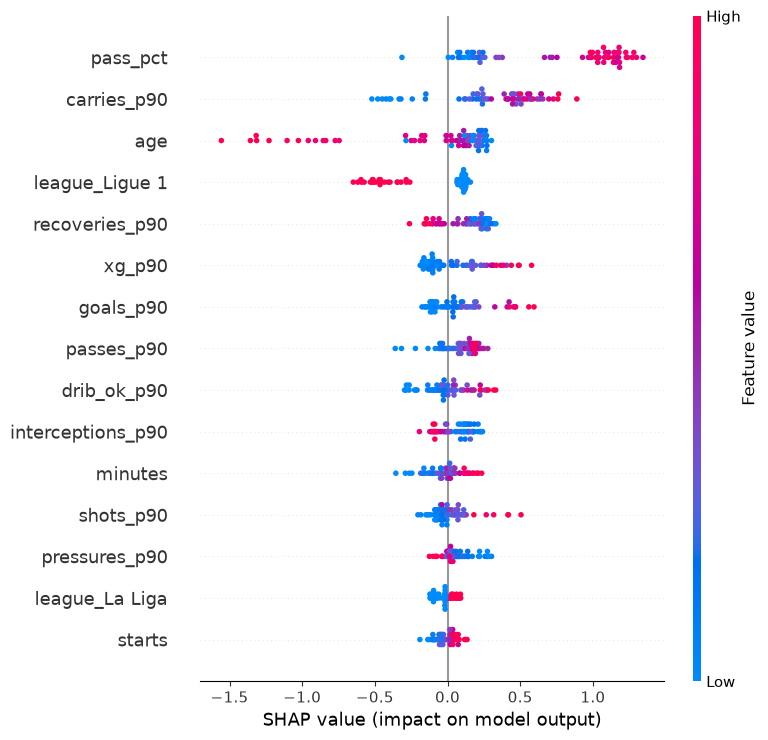

In [6]:
import shap

winner = {'random_forest': rf, 'xgboost': xgb}[best_cv]
explainer = shap.TreeExplainer(winner)
sv = explainer.shap_values(Xte)
imp = pd.Series(abs(sv).mean(axis=0), index=Xte.columns).sort_values(ascending=False)
print(imp.round(4).head(15).to_string())
shap.summary_plot(sv, Xte, max_display=15, show=False)
plt.tight_layout()


## Cell 7 — Is pass completion's crown league-wide?

Cell 6 pools all players, so one club's system can top the ranking. This cell re-ranks features separately per league (training rows, for readable samples) plus a Barcelona-vs-rest split. A universal pricing signal tops every league; a composition effect tops only its home. Samples under 20 rows are reported and ignored.

In [7]:
sv_tr = explainer.shap_values(Xtr)
S = pd.DataFrame(np.abs(sv_tr), columns=Xtr.columns)
S['league'] = df.loc[train, 'league_season'].apply(lambda s: s.rsplit(' ', 1)[0]).values
S['is_barca'] = (df.loc[train, 'sb_team'].values == 'Barcelona')
print('rows per league:')
print(S['league'].value_counts().to_string())
for lg, g in S.groupby('league'):
    feats_only = g.drop(columns=['league', 'is_barca'])
    if len(g) < 20:
        print(lg, 'n=%d \u2014 too small to read' % len(g))
        continue
    top = feats_only.mean().sort_values(ascending=False)
    print(lg, '| top3:', list(top.head(3).index),
          '| pass_pct rank:', int((top > top['pass_pct']).sum()) + 1)
print()
for flag, name in [(True, 'Barcelona'), (False, 'rest')]:
    top = S[S['is_barca'] == flag].drop(columns=['league', 'is_barca']).mean().sort_values(ascending=False)
    print(name, '| top3:', list(top.head(3).index),
          '| pass_pct rank:', int((top > top['pass_pct']).sum()) + 1)


rows per league:
league
Serie A           254
La Liga           250
Premier League    210
Ligue 1           186
1. Bundesliga      10
1. Bundesliga n=10 — too small to read
La Liga | top3: ['pass_pct', 'carries_p90', 'age'] | pass_pct rank: 1
Ligue 1 | top3: ['league_Ligue 1', 'carries_p90', 'age'] | pass_pct rank: 4
Premier League | top3: ['carries_p90', 'league_Premier League', 'age'] | pass_pct rank: 4
Serie A | top3: ['age', 'carries_p90', 'xg_p90'] | pass_pct rank: 4

Barcelona | top3: ['pass_pct', 'carries_p90', 'age'] | pass_pct rank: 1
rest | top3: ['carries_p90', 'age', 'pass_pct'] | pass_pct rank: 3


## Cell 8 — Undervalued-player hunt (out-of-fold predictions)

Predicted minus actual in euros, where each row was judged by a model that never saw that player. Largest gaps first. Language matters (handover rule): these are *potentially* undervalued *according to the model* — price reflects contracts, age curves, injuries, and club politics the model never sees. The table is a shortlist generator, not a valuation certificate.

In [8]:
pred_ln = oof[best_cv]
out = df[['league_season', 'sb_player', 'sb_team', 'position', 'minutes']].copy()
out['actual_eur_M'] = np.expm1(y.values).round(-5) / 1e6
out['pred_eur_M'] = np.expm1(pred_ln).round(-5) / 1e6
out['gap_eur_M'] = (out['pred_eur_M'] - out['actual_eur_M']).round(1)
print(out.sort_values('gap_eur_M', ascending=False).head(12).to_string())


                league_season                        sb_player     sb_team                   position  minutes  actual_eur_M  pred_eur_M  gap_eur_M
301         La Liga 2020/2021            Óscar Mingueza García   Barcelona          Right Center Back   777.67          15.0   58.400002       43.4
35          La Liga 2012/2013  Pedro Eliezer Rodríguez Ledesma   Barcelona                 Right Wing  1224.94          22.0   65.099998       43.1
56          La Liga 2014/2015  Pedro Eliezer Rodríguez Ledesma   Barcelona                 Right Wing   995.05          20.0   62.500000       42.5
55          La Liga 2014/2015    Neymar da Silva Santos Junior   Barcelona                  Left Wing   944.27          80.0  110.900002       30.9
148         La Liga 2015/2016     José Vicente Gómez Umpiérrez  Las Palmas    Left Defensive Midfield   650.64           1.2   26.299999       25.1
138         La Liga 2015/2016             Jonathan Viera Ramos  Las Palmas                  Left Wing  1317.87  

## Next steps

1. Read Cells 4 and 5 as one story: within-regime skill (CV R²) next to forward-generalization failure (time-split R²), with causes named.
2. Commit this notebook: the Day-4 milestone closes Phase 1 modeling — limits first.
3. Day 5: README story (problem, data, method, results, limits, next) and the public push.